<a href="https://colab.research.google.com/github/Art207141/Labs_sbor_analyz/blob/main/lab02/lab02_part2/Lab02_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2 (часть 2)

## **Часть 0. Подготовка данных**

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Установка сида для воспроизводимости
np.random.seed(2024)

# Списки базовых значений для генерации данных
cities = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Челябинск"]
categories = ["Электроника", "Одежда", "Дом", "Красота", "Спорт"]
statuses = ["Доставлен", "Отменён", "Возврат"]
payments = ["Карта", "Онлайн", "Наличные"]

# Словарик товаров по категориям
products_pool = {
    "Электроника": ["Смартфон", "Наушники", "Ноутбук", "Умные часы", "Пауэрбанк"],
    "Одежда": ["Футболка", "Джинсы", "Худи", "Куртка", "Кроссовки"],
    "Дом": ["Лампа", "Подушка", "Плед", "Посуда", "Увлажнитель воздуха"],
    "Красота": ["Крем для лица", "Шампунь", "Сыворотка", "Духи", "Маска для волос"],
    "Спорт": ["Коврик для йоги", "Гантели", "Бутылка для воды", "Эспандер", "Рюкзак"]
}

n_orders = 3000

# Генерация базовых списков
order_ids = [f"{i:04d}" for i in range(1, n_orders + 1)]
order_dates = pd.date_range(start="2026-01-01", end="2026-12-31", periods=n_orders)
customer_ids = [f"{np.random.randint(1, 800):03d}" for _ in range(n_orders)]
order_cities = np.random.choice(cities, size=n_orders)
ages = np.random.randint(14, 75, size=n_orders)
is_vips = np.random.choice([True, False], size=n_orders, p=[0.15, 0.85])

gen_categories = np.random.choice(categories, size=n_orders)
product_names = [np.random.choice(products_pool[cat]) for cat in gen_categories]

quantities = np.random.randint(1, 6, size=n_orders)
prices = np.random.choice([500, 1000, 1500, 3000, 5000, 8000, 12000], size=n_orders)
discounts = np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20, 0.30], size=n_orders, p=[0.5, 0.1, 0.1, 0.1, 0.1, 0.1])
costs = prices * np.random.uniform(0.4, 0.7, size=n_orders) # Себестоимость как % от базовой цены

gen_statuses = np.random.choice(statuses, size=n_orders, p=[0.75, 0.15, 0.10])
gen_payments = np.random.choice(payments, size=n_orders)

# Сборка датафрейма
df = pd.DataFrame({
    "order_id": order_ids,
    "order_date": order_dates,
    "customer_id": customer_ids,
    "city": order_cities,
    "age": ages,
    "is_vip": is_vips,
    "product_name": product_names,
    "category": gen_categories,
    "quantity": quantities,
    "price": prices,
    "discount": discounts,
    "cost": costs,
    "status": gen_statuses,
    "payment": gen_payments
})

# Добавление ровно 30 пропущенных значений в age
nan_indices = np.random.choice(df.index, size=30, replace=False)
df.loc[nan_indices, "age"] = np.nan

df

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
0,0001,2026-01-01 00:00:00.000000000,649,Челябинск,30.0,False,Ноутбук,Электроника,1,1500,0.00,700.328900,Возврат,Карта
1,0002,2026-01-01 02:54:46.695565188,507,Казань,71.0,False,Джинсы,Одежда,3,1500,0.00,708.080988,Доставлен,Онлайн
2,0003,2026-01-01 05:49:33.391130376,609,Екатеринбург,64.0,False,Увлажнитель воздуха,Дом,1,500,0.00,314.238089,Отменён,Онлайн
3,0004,2026-01-01 08:44:20.086695565,641,Санкт-Петербург,22.0,False,Эспандер,Спорт,2,1000,0.05,542.020415,Доставлен,Карта
4,0005,2026-01-01 11:39:06.782260753,540,Екатеринбург,61.0,False,Бутылка для воды,Спорт,3,5000,0.00,2409.582882,Доставлен,Онлайн
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,2026-12-30 12:20:53.217739248,635,Москва,36.0,False,Рюкзак,Спорт,3,12000,0.00,5073.840440,Доставлен,Онлайн
2996,2997,2026-12-30 15:15:39.913304436,555,Челябинск,67.0,False,Духи,Красота,4,1000,0.05,699.154963,Доставлен,Карта
2997,2998,2026-12-30 18:10:26.608869624,525,Екатеринбург,40.0,False,Подушка,Дом,3,12000,0.20,5357.502544,Доставлен,Карта
2998,2999,2026-12-30 21:05:13.304434812,780,Челябинск,54.0,False,Лампа,Дом,1,12000,0.20,6316.058645,Доставлен,Онлайн


## **Часть 1. Первичный анализ данных**

In [101]:
print("--- Shape ---")
print(df.shape)
print("\n--- Info ---")
df.info()
print("\n--- Head ---")
print(df.head())
print("\n--- Tail ---")
print(df.tail())
print("\n--- Describe ---")
print(df.describe(include='all'))
print("\n--- Missing Values ---")
print(df.isna().sum())

--- Shape ---
(3000, 14)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3000 non-null   object        
 1   order_date    3000 non-null   datetime64[ns]
 2   customer_id   3000 non-null   object        
 3   city          3000 non-null   object        
 4   age           2970 non-null   float64       
 5   is_vip        3000 non-null   bool          
 6   product_name  3000 non-null   object        
 7   category      3000 non-null   object        
 8   quantity      3000 non-null   int64         
 9   price         3000 non-null   int64         
 10  discount      3000 non-null   float64       
 11  cost          3000 non-null   float64       
 12  status        3000 non-null   object        
 13  payment       3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(3), int64(

Ответы на вопросы
1. Сколько строк и столбцов в DataFrame?

3000 строк и 14 столбцов

2. В каких столбцах есть пропуски?

в столбце age

3. Сколько пропусков в age?

30 пропусков

4. Сколько уникальных клиентов?

786 уникальных клиентов

5. Сколько уникальных товаров?

25 уникальных товаров

6. Какие города представлены в данных?

Челябинск, Казань, Екатеринбург, Санкт-Петербург, Москва

7. Какие категории товаров есть?

Электроника, Одежда, Дом, Спорт, Красота

8. Какие способы оплаты используются?

Карта, Онлайн, Наличные

# **Часть 2. Подготовка данных**

## 2.1. Работа с датой

In [102]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
print(df[["order_date","year", "month"]])
# Прибыль может быть отрицательной, если себестоимость (cost) закупки
# или производства товара оказалась выше, чем итоговая цена продажи с учетом скидки.

                        order_date  year  month
0    2026-01-01 00:00:00.000000000  2026      1
1    2026-01-01 02:54:46.695565188  2026      1
2    2026-01-01 05:49:33.391130376  2026      1
3    2026-01-01 08:44:20.086695565  2026      1
4    2026-01-01 11:39:06.782260753  2026      1
...                            ...   ...    ...
2995 2026-12-30 12:20:53.217739248  2026     12
2996 2026-12-30 15:15:39.913304436  2026     12
2997 2026-12-30 18:10:26.608869624  2026     12
2998 2026-12-30 21:05:13.304434812  2026     12
2999 2026-12-31 00:00:00.000000000  2026     12

[3000 rows x 3 columns]


## 2.2. Расчёт выручки и прибыли

In [103]:
df["revenue"] = (df["price"] * df["quantity"] * (1 - df["discount"]))

df["profit"] = df["revenue"] - df["cost"]
print(df[["revenue","cost", "profit"]])

      revenue         cost        profit
0      1500.0   700.328900    799.671100
1      4500.0   708.080988   3791.919012
2       500.0   314.238089    185.761911
3      1900.0   542.020415   1357.979585
4     15000.0  2409.582882  12590.417118
...       ...          ...           ...
2995  36000.0  5073.840440  30926.159560
2996   3800.0   699.154963   3100.845037
2997  28800.0  5357.502544  23442.497456
2998   9600.0  6316.058645   3283.941355
2999   6000.0  1681.754017   4318.245983

[3000 rows x 3 columns]


## 2.3. Реальная продажа

In [104]:
df["is_real_sale"] = df["status"] == "Доставлен"

print(df[["status", "is_real_sale"]])
# При расчете фактической выручки важно учитывать только доставленные заказы,
# так как по отмененным заказам и возвратам деньги либо не поступают, либо возвращаются клиенту.

         status  is_real_sale
0       Возврат         False
1     Доставлен          True
2       Отменён         False
3     Доставлен          True
4     Доставлен          True
...         ...           ...
2995  Доставлен          True
2996  Доставлен          True
2997  Доставлен          True
2998  Доставлен          True
2999  Доставлен          True

[3000 rows x 2 columns]


## 2.4. Пропуски в возрасте

In [105]:
median_age = df["age"].median()

df["age"] = df["age"].fillna(median_age)

print(median_age)
df["age"].isna().sum()

44.0


np.int64(0)

## 2.5. Возрастные группы

In [106]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["до 18", "18–30", "31–45", "46–60", "60+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
print(df[["age", "age_group"]])

       age age_group
0     30.0     18–30
1     71.0       60+
2     64.0       60+
3     22.0     18–30
4     61.0       60+
...    ...       ...
2995  36.0     31–45
2996  67.0       60+
2997  40.0     31–45
2998  54.0     46–60
2999  23.0     18–30

[3000 rows x 2 columns]


# **Часть 3. Фильтрация данных**

In [107]:
print("Задание 1 (Количество товаров > 3):", len(df[df["quantity"] > 3]))
print("Задание 2 (Клиенты из Москвы):", len(df[df["city"] == "Москва"]))
print("Задание 3 (VIP-заказы):", len(df[df["is_vip"] == True]))
print("Задание 4 (Цена > 5000):", len(df[df["price"] > 5000]))
print("Задание 5 (Скидка > 20%):", len(df[df["discount"] > 0.20]))

print("\nЗадание 6 (Статусы заказов):")
print(df["status"].value_counts())

Задание 1 (Количество товаров > 3): 1230
Задание 2 (Клиенты из Москвы): 569
Задание 3 (VIP-заказы): 459
Задание 4 (Цена > 5000): 889
Задание 5 (Скидка > 20%): 273

Задание 6 (Статусы заказов):
status
Доставлен    2247
Отменён       454
Возврат       299
Name: count, dtype: int64


## Сложные фильтры

In [108]:
filter_7 = df[(df["city"] == "Москва") & (df["revenue"] > 5000)]
print("Задание 7 (Москва и выручка > 5000):", len(filter_7))

filter_8 = df[(df["is_vip"] == True) & (df["category"] == "Электроника")]
print("Задание 8 (VIP и Электроника):", len(filter_8))

filter_9 = df[(df["status"] == "Доставлен") & (df["payment"] == "Онлайн")]
print("Задание 9 (Доставлен и Онлайн):", len(filter_9))

filter_10 = df[df["year"] == 2026]
print("Задание 10 (За 2024 год):", len(filter_10))

filter_11 = df[(df["year"] == 2026) & (df["month"] == 1)]
print("Задание 11 (За январь 2024):", len(filter_11))

Задание 7 (Москва и выручка > 5000): 329
Задание 8 (VIP и Электроника): 82
Задание 9 (Доставлен и Онлайн): 765
Задание 10 (За 2024 год): 3000
Задание 11 (За январь 2024): 256


## Поиск экстремальных значений

In [109]:
print("1. Заказ с макс. выручкой:")
print(df.loc[[df["revenue"].idxmax()]])

print("\n2. Заказ с макс. скидкой:")
print(df.loc[[df["discount"].idxmax()]])

print("\n3. Заказ с макс. прибылью:")
print(df.loc[[df["profit"].idxmax()]])

print("\n4. Самый молодой заказ (по возрасту клиента):")
print(df.loc[[df["age"].idxmin()]])

print("\n5. Самый старший заказ (по возрасту клиента):")
print(df.loc[[df["age"].idxmax()]])

1. Заказ с макс. выручкой:
   order_id                    order_date customer_id             city   age  \
34     0035 2026-01-05 03:02:27.649216405         796  Санкт-Петербург  23.0   

    is_vip product_name category  quantity  price  discount         cost  \
34   False       Джинсы   Одежда         5  12000       0.0  8038.682029   

       status   payment  year  month  revenue        profit  is_real_sale  \
34  Доставлен  Наличные  2026      1  60000.0  51961.317971          True   

   age_group  
34     18–30  

2. Заказ с макс. скидкой:
   order_id                    order_date customer_id    city   age  is_vip  \
26     0027 2026-01-04 03:44:14.084694898         055  Казань  26.0   False   

   product_name category  quantity  price  discount         cost   status  \
26         Худи   Одежда         4   8000       0.3  4269.483549  Возврат   

   payment  year  month  revenue        profit  is_real_sale age_group  
26  Онлайн  2026      1  22400.0  18130.516451         False

# **Часть 4. Группировка данных**

## Задание 1. Выручка по категориям

In [110]:
print("Задание 1. Выручка по категориям:")
rev_by_cat = df.groupby("category")["revenue"].sum()
print(rev_by_cat)
print(f"Категория с максимальной выручкой: {rev_by_cat.idxmax()}")

Задание 1. Выручка по категориям:
category
Дом            7700700.0
Красота        7512375.0
Одежда         7649875.0
Спорт          7106200.0
Электроника    7424425.0
Name: revenue, dtype: float64
Категория с максимальной выручкой: Дом


## Задание 2. Средняя выручка

In [111]:
print("\nЗадание 2. Средняя выручка заказа по категориям:")
print(df.groupby("category")["revenue"].mean())


Задание 2. Средняя выручка заказа по категориям:
category
Дом            12770.646766
Красота        12604.656040
Одежда         12318.639291
Спорт          12105.962521
Электроника    12520.109612
Name: revenue, dtype: float64


## Задание 3. Количество заказов

In [112]:
print("\nЗадание 3. Количество заказов в каждой категории:")
print(df.groupby("category")["order_id"].count())


Задание 3. Количество заказов в каждой категории:
category
Дом            603
Красота        596
Одежда         621
Спорт          587
Электроника    593
Name: order_id, dtype: int64


## Задание 4. Средняя скидка

In [113]:
print("\nЗадание 4. Средняя скидка по категориям:")
print(df.groupby("category")["discount"].mean())


Задание 4. Средняя скидка по категориям:
category
Дом            0.083416
Красота        0.081040
Одежда         0.076812
Спорт          0.078961
Электроника    0.084654
Name: discount, dtype: float64


## Задание 5. Категория и город

In [114]:
print("\nЗадание 5. Категория и город (Выручка):")
print(df.groupby(["category", "city"])["revenue"].sum())


Задание 5. Категория и город (Выручка):
category     city           
Дом          Екатеринбург       1898300.0
             Казань             1352200.0
             Москва             1677975.0
             Санкт-Петербург    1450625.0
             Челябинск          1321600.0
Красота      Екатеринбург       1584325.0
             Казань             1643350.0
             Москва             1501725.0
             Санкт-Петербург    1414100.0
             Челябинск          1368875.0
Одежда       Екатеринбург       1689750.0
             Казань             1757175.0
             Москва             1192275.0
             Санкт-Петербург    1595800.0
             Челябинск          1414875.0
Спорт        Екатеринбург       1462225.0
             Казань             1295775.0
             Москва             1309925.0
             Санкт-Петербург    1490800.0
             Челябинск          1547475.0
Электроника  Екатеринбург       1722175.0
             Казань             1160000.0
      

## Задание 6. VIP-клиенты

In [115]:
print("\nЗадание 6. Средняя выручка VIP-заказов по городам:")
print(df[df["is_vip"] == True].groupby("city")["revenue"].mean())


Задание 6. Средняя выручка VIP-заказов по городам:
city
Екатеринбург       14968.932039
Казань             11181.043956
Москва             13063.055556
Санкт-Петербург    11993.354430
Челябинск          12751.822917
Name: revenue, dtype: float64


## Задание 7. Способ оплаты

In [116]:
print("\nЗадание 7. Количество заказов по городам и способам оплаты:")
print(df.groupby(["city", "payment"])["order_id"].count())


Задание 7. Количество заказов по городам и способам оплаты:
city             payment 
Екатеринбург     Карта       235
                 Наличные    222
                 Онлайн      189
Казань           Карта       192
                 Наличные    186
                 Онлайн      190
Москва           Карта       198
                 Наличные    192
                 Онлайн      179
Санкт-Петербург  Карта       176
                 Наличные    199
                 Онлайн      210
Челябинск        Карта       191
                 Наличные    192
                 Онлайн      249
Name: order_id, dtype: int64


## Задание 8. Несколько показателей

In [117]:
print("\nЗадание 8. Несколько показателей по категориям:")
agg_report = df.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_discount=("discount", "mean"),
    profit=("profit", "sum")
)
print(agg_report)


Задание 8. Несколько показателей по категориям:
             orders    revenue   avg_revenue  avg_discount        profit
category                                                                
Дом             603  7700700.0  12770.646766      0.083416  6.176077e+06
Красота         596  7512375.0  12604.656040      0.081040  6.092657e+06
Одежда          621  7649875.0  12318.639291      0.076812  6.162713e+06
Спорт           587  7106200.0  12105.962521      0.078961  5.639573e+06
Электроника     593  7424425.0  12520.109612      0.084654  5.950847e+06


# **Часть 5. Визуализация**

## Задание 1. Распределение возраста

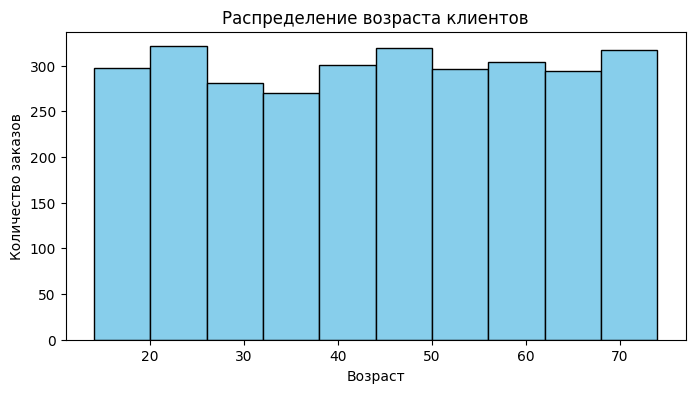

In [118]:
plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=10, color='skyblue', edgecolor='black')
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.show()

## Задание 2. Распределение выручки

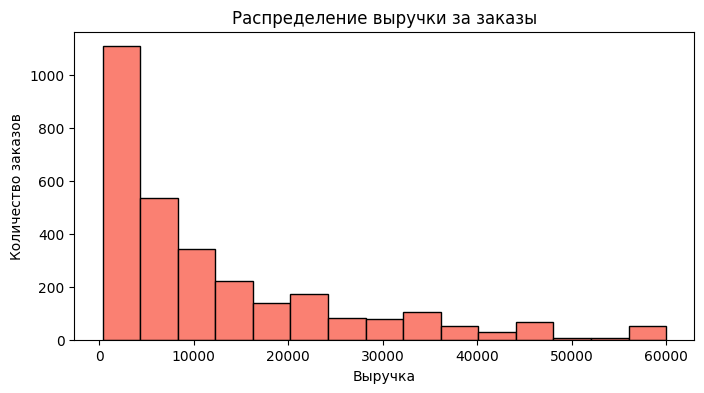

In [119]:
plt.figure(figsize=(8, 4))
plt.hist(df["revenue"], bins=15, color='salmon', edgecolor='black')
plt.title("Распределение выручки за заказы")
plt.xlabel("Выручка")
plt.ylabel("Количество заказов")
plt.show()

## Задание 3. Распределение скидки

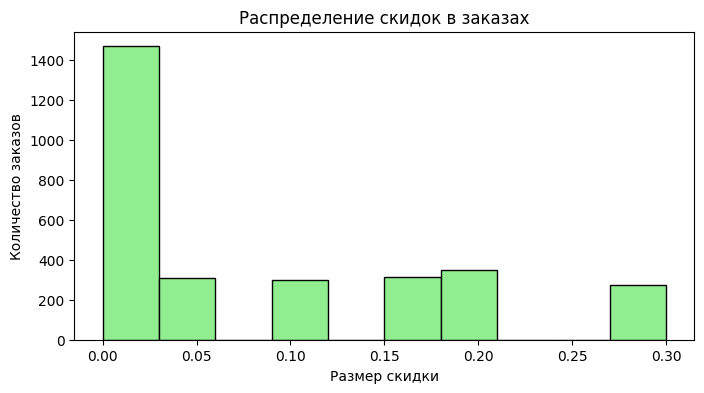

In [120]:
plt.figure(figsize=(8, 4))
plt.hist(df["discount"], bins=10, color='lightgreen', edgecolor='black')
plt.title("Распределение скидок в заказах")
plt.xlabel("Размер скидки")
plt.ylabel("Количество заказов")
plt.show()

## Задание 4. VIP и обычные клиенты

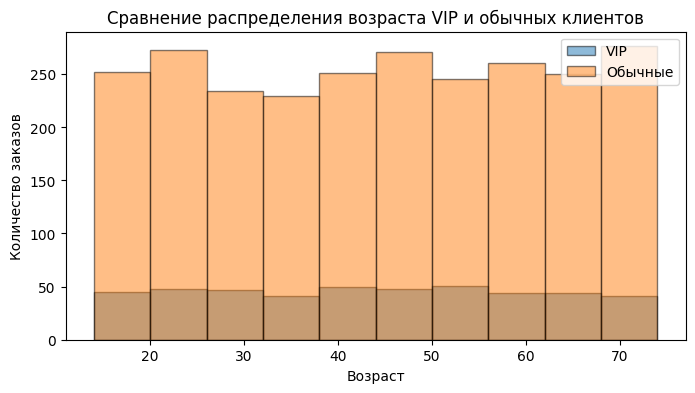

In [121]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["is_vip"] == True]["age"], alpha=0.5, label='VIP', bins=10, edgecolor='black')
plt.hist(df[df["is_vip"] == False]["age"], alpha=0.5, label='Обычные', bins=10, edgecolor='black')
plt.title("Сравнение распределения возраста VIP и обычных клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.legend()
plt.show()

## Задание 5. Выручка по категориям

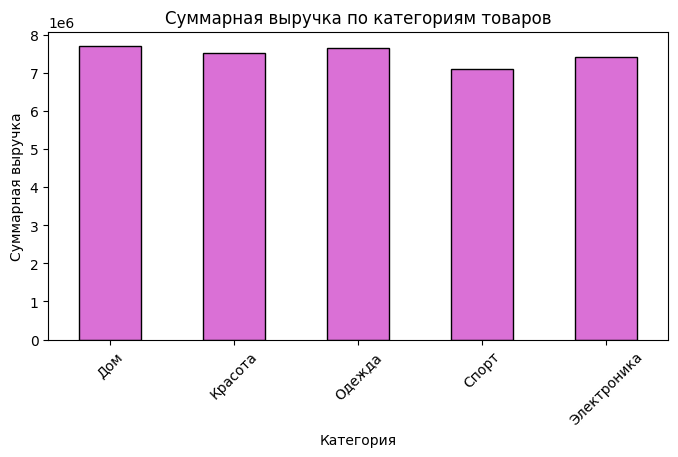

In [122]:
plt.figure(figsize=(8, 4))
df.groupby("category")["revenue"].sum().plot(kind='bar', color='orchid', edgecolor='black')
plt.title("Суммарная выручка по категориям товаров")
plt.xlabel("Категория")
plt.ylabel("Суммарная выручка")
plt.xticks(rotation=45)
plt.show()

## Задание 6. Заказы по городам

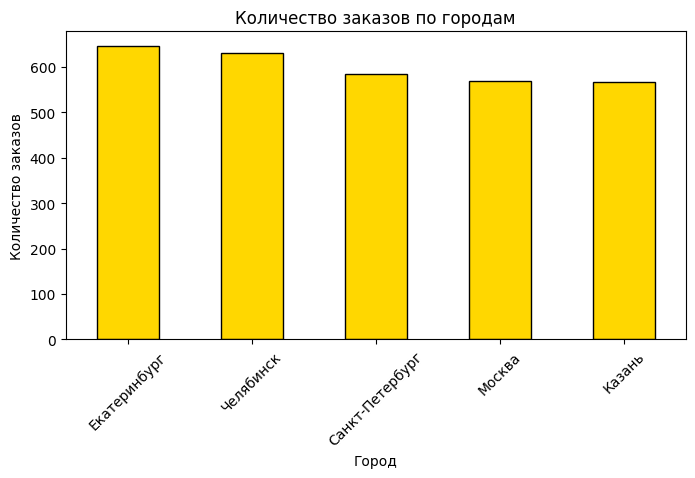

In [123]:
plt.figure(figsize=(8, 4))
df["city"].value_counts().plot(kind='bar', color='gold', edgecolor='black')
plt.title("Количество заказов по городам")
plt.xlabel("Город")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.show()

## Задание 7. Возрастные группы

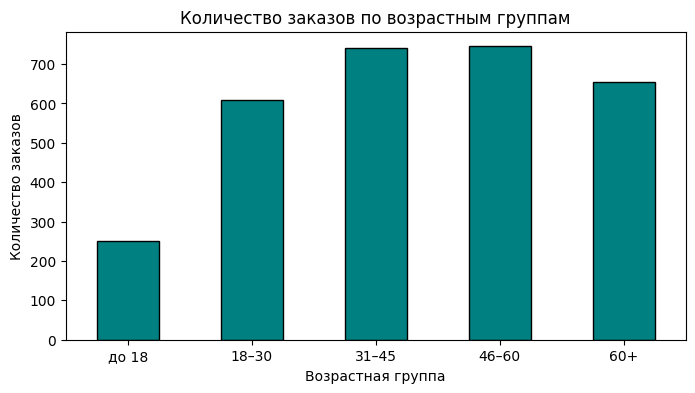

In [124]:
plt.figure(figsize=(8, 4))
df["age_group"].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black')
plt.title("Количество заказов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.show()

## Задание 8. Статусы заказов

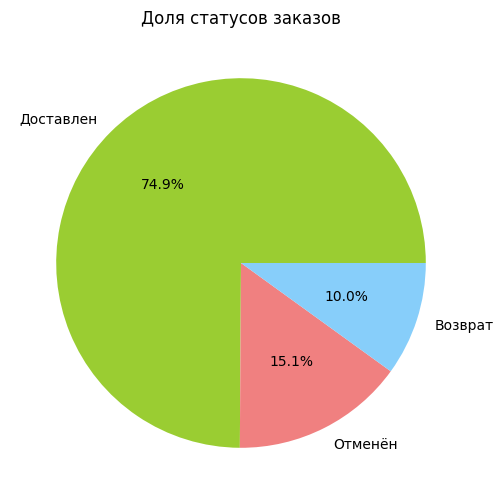

In [125]:
plt.figure(figsize=(6, 6))
df["status"].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['yellowgreen', 'lightcoral', 'lightskyblue'])
plt.title("Доля статусов заказов")
plt.ylabel("")
plt.show()

## Задание 9. Выручка по месяцам

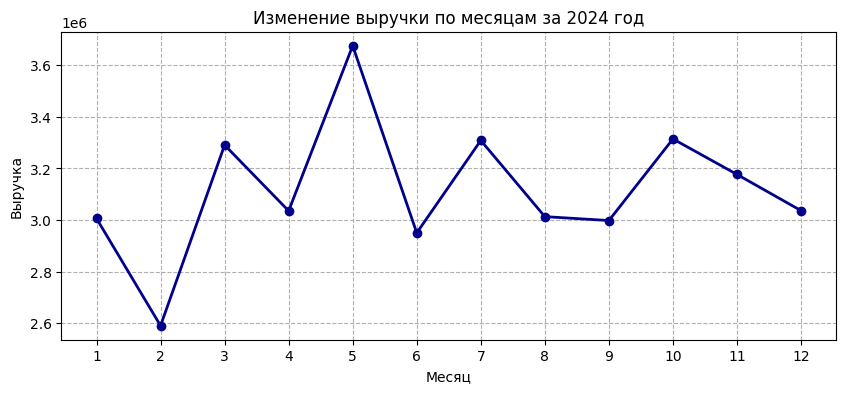

In [126]:
monthly = df.groupby(["year", "month"])["revenue"].sum().reset_index()
plt.figure(figsize=(10, 4))
plt.plot(monthly["month"], monthly["revenue"], marker='o', color='darkblue', linewidth=2)
plt.title("Изменение выручки по месяцам за 2024 год")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.grid(True, linestyle='--')
plt.xticks(range(1, 13))
plt.show()
# Вывод по графику: На графике видно, как выручка колеблется от месяца к месяцу.
# В зависимости от случайно сгенерированных данных наблюдаются пики продаж в отдельные периоды.

# **Часть 6. Мини-анализ**

In [127]:
# Задание 1. Общая статистика
total_orders = len(df)
total_revenue = df["revenue"].sum()
avg_order_revenue = df["revenue"].mean()
print(f"Всего заказов: {total_orders}, Выручка: {total_revenue:.2f}, Средний чек: {avg_order_revenue:.2f}")
# Вывод: Наш магазин показывает стабильный средний чек. Большой объем заказов формирует высокую суммарную выручку.

# Задание 2. Категории
cat_rev = df.groupby("category")["revenue"].sum()
print(f"Макс: {cat_rev.idxmax()} ({cat_rev.max():.2f}), Мин: {cat_rev.idxmin()} ({cat_rev.min():.2f})")
# Вывод: Самой успешной категорией стала Дом. Меньше всего денег принесла категория Спорт.

# Задание 3. VIP-заказы
vip_revenue = df.loc[df["is_vip"] == True, "revenue"].sum()
vip_share = (vip_revenue / total_revenue) * 100
print(f"Доля выручки VIP: {vip_share:.2f}%")
# Вывод: VIP-клиенты создают около 15,8% всей выручки.

# Задание 4. Скидки
print(df.groupby("discount")["revenue"].mean())
# Вывод: С увеличением размера скидки средняя выручка с одного заказа ожидаемо падает, так как итоговая стоимость уменьшается.

# Задание 5. Возвраты и отмены
bad_statuses = df[df["status"].isin(["Отменён", "Возврат"])].groupby(["category", "status"])["order_id"].count()
print(bad_statuses)
# Вывод: Больше всего отмен и возвратов зафиксировано в категориях с наибольшим числом заказов, что является естественной закономерностью.

Всего заказов: 3000, Выручка: 37393575.00, Средний чек: 12464.52
Макс: Дом (7700700.00), Мин: Спорт (7106200.00)
Доля выручки VIP: 15.80%
discount
0.00    13268.076398
0.05    13027.687296
0.10    11402.027027
0.15    12814.022436
0.20    11351.445087
0.30     9679.487179
Name: revenue, dtype: float64
category     status 
Дом          Возврат     62
             Отменён     92
Красота      Возврат     57
             Отменён     77
Одежда       Возврат     67
             Отменён     88
Спорт        Возврат     60
             Отменён     97
Электроника  Возврат     53
             Отменён    100
Name: order_id, dtype: int64


# **Часть 7. Итоговый вывод**

1. Наиболее значимыми категориями товаров по выручке стали Дом и Одежда, которые лидируют за счет высокой базовой стоимости товаров.
2. Основной объем заказов распределен относительно равномерно между крупнейшими городами, однако Екатеринбург и Челябинск дают больше заказов.
3. Доля выручки от VIP-клиентов составляет около 15%, что подчеркивает важность работы с лояльной аудиторией.
4. Анализ скидок показал, что частое предоставление скидок свыше 20% заметно снижает средний чек, поэтому их нужно применять аккуратно.
5. Количество возвратов и отмен коррелирует с общим объемом продаж в категориях и держится в рамках нормы (около 25% в сумме).
6. В качестве дополнительного исследования было бы полезно изучить пожизненную ценность клиента и проанализировать сезонность продаж конкретных товаров по кварталам.